In [ ]:
# === Initialisation : chargement du dataset ===
import os
import pandas as pd

data_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "data", "COVID-19_Radiography_Dataset")

data = []
for category in os.listdir(data_dir):
    folder_images = os.path.join(data_dir, category, "images")
    if os.path.isdir(folder_images):
        for file in os.listdir(folder_images):
            if file.endswith(".png") or file.endswith(".jpg"):
                data.append({
                    "image_path": os.path.join(folder_images, file),
                    "label": category
                })

df_images = pd.DataFrame(data)
print(f"Dataset charge : {len(df_images)} images")
print(df_images['label'].value_counts())

In [ ]:
# === Initialisation : preprocessing des images ===
import numpy as np
from PIL import Image

TARGET_SIZE = (256, 256)

def preprocess_image(path):
    img = Image.open(path).convert('L')
    img = img.resize(TARGET_SIZE)
    img_array = np.array(img, dtype=np.float32) / 255.0
    return img_array

print("Preprocessing des images...")
X_list = [preprocess_image(p) for p in df_images['image_path']]
print(f"X_list : {len(X_list)} images preprocessees")

In [ ]:
# === Initialisation : preparation des donnees pour modelisation ===
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

TARGET_SIZE_SMALL = (64, 64)
X_small = np.array([cv2.resize(img, TARGET_SIZE_SMALL) for img in X_list], dtype=np.float32) / 255.0
X_flat = X_small.reshape(X_small.shape[0], -1)

le = LabelEncoder()
y = le.fit_transform(df_images['label'].values)

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Classes: {list(le.classes_)}")

In [ ]:
# === Initialisation : entrainement du baseline RF ===
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest baseline entraine")

In [19]:
# ============================================================
# STEP 2 – Optimisation + Métriques 
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

print("\n=== STEP 2 : OPTIMISATION DU MODELE ===")

# ------------------------------------------------------------
# 1) Hyperparamètres à tester (grille réduite pour éviter blocage)
# ------------------------------------------------------------
# Au lieu de tester 81 combinaisons comme ton GridSearch (3x3x3x3),
# on réduit volontairement pour que ton PC ne plante pas.
param_dist = {
    'n_estimators': [100, 150],       # nombre d’arbres raisonnable
    'max_depth': [None, 15],          # profondeur contrôlée
    'min_samples_split': [2, 5],      # valeurs simples
    'min_samples_leaf': [1, 2]        # évite le surapprentissage
}

# ------------------------------------------------------------
# 2) Configuration de RandomizedSearchCV
# ------------------------------------------------------------
# RandomizedSearch teste un échantillon aléatoire de combinaisons
# → beaucoup plus léger que GridSearchCV
optim_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=5,                # Nombre total de modèles testés → très léger
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1                # Utilise tous les cœurs sans bloquer (car grille réduite)
)

# ------------------------------------------------------------
# 3) Entraînement
# ------------------------------------------------------------
print("\nRecherche des meilleurs hyperparamètres...")
optim_rf.fit(X_train, y_train)

# Modèle optimal trouvé
best_rf = optim_rf.best_estimator_
print("🟩 Meilleurs paramètres trouvés :", optim_rf.best_params_)

# ------------------------------------------------------------
# 4) Évaluation du modèle optimisé
# ------------------------------------------------------------
print("\n=== EVALUATION ===")

y_pred = best_rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc:.4f}")

print("\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred))

print("\nRapport de classification :")
print(classification_report(y_test, y_pred))



=== STEP 2 : OPTIMISATION DU MODELE ===

Recherche des meilleurs hyperparamètres...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
🟩 Meilleurs paramètres trouvés : {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

=== EVALUATION ===
Accuracy : 0.8254

Matrice de confusion :
[[ 509   83  127    4]
 [  18  895  289    1]
 [  30  127 1874    7]
 [   9    9   35  216]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.90      0.70      0.79       723
           1       0.80      0.74      0.77      1203
           2       0.81      0.92      0.86      2038
           3       0.95      0.80      0.87       269

    accuracy                           0.83      4233
   macro avg       0.86      0.79      0.82      4233
weighted avg       0.83      0.83      0.82      4233




F1-score macro : 0.8226
F1-score micro : 0.8254


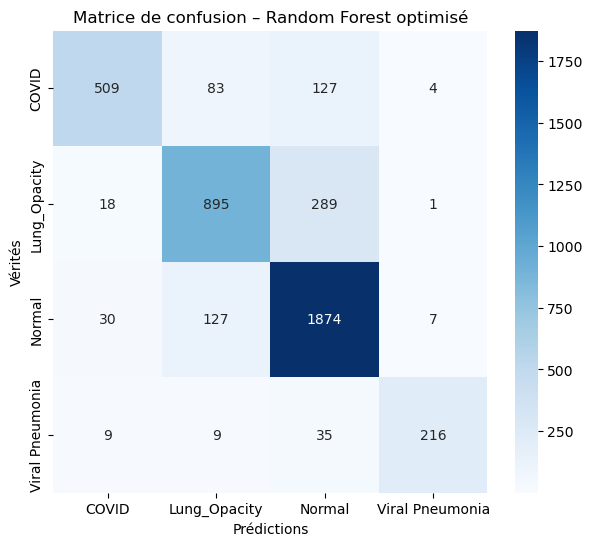


=== Tableau synthétique par classe ===
COVID           | Precision: 0.90 | Recall: 0.70 | F1-score: 0.79 | Support: 723.0
Lung_Opacity    | Precision: 0.80 | Recall: 0.74 | F1-score: 0.77 | Support: 1203.0
Normal          | Precision: 0.81 | Recall: 0.92 | F1-score: 0.86 | Support: 2038.0
Viral Pneumonia | Precision: 0.95 | Recall: 0.80 | F1-score: 0.87 | Support: 269.0


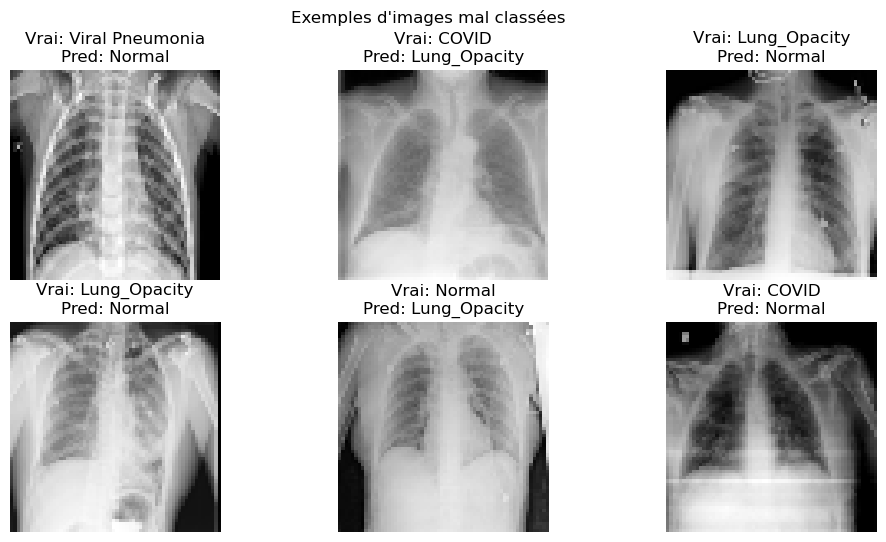

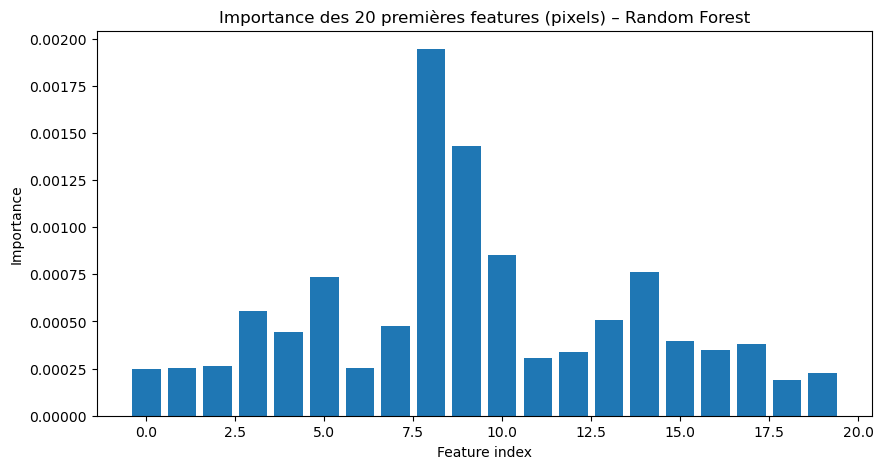

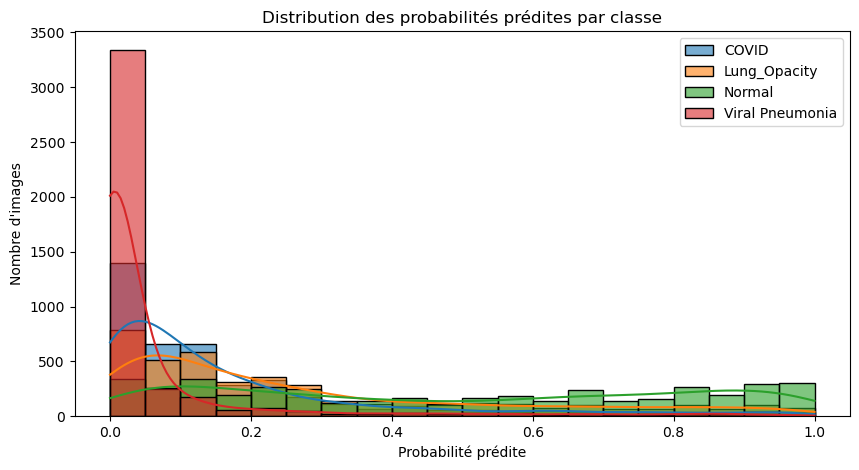

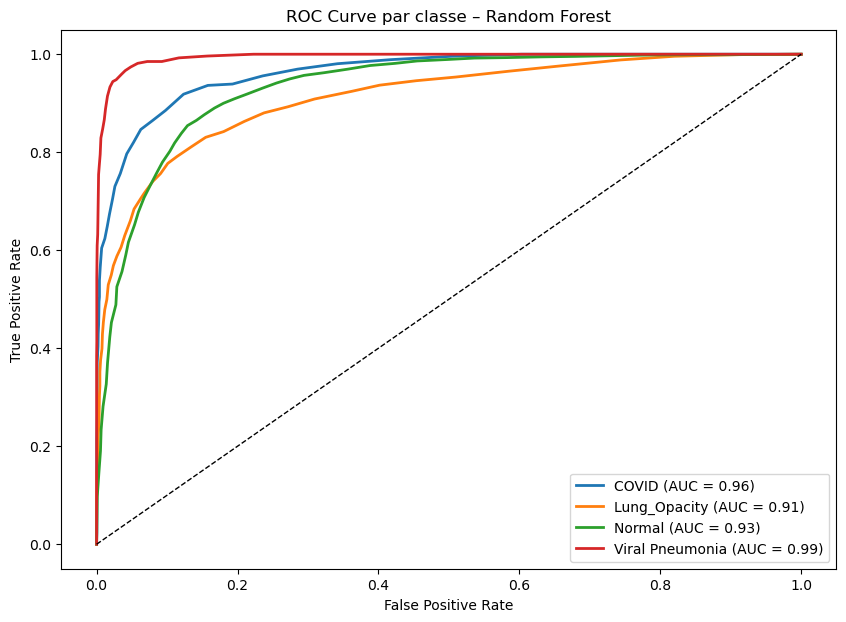

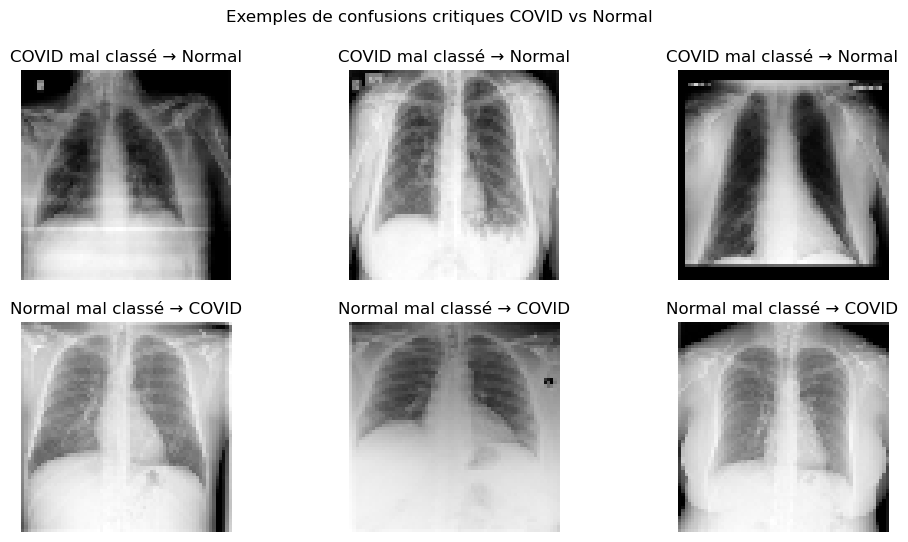


Commentaire pédagogique :
- La précision globale est correcte (~82%).
- Certaines classes comme 'COVID' et 'Normal' sont plus difficiles à distinguer.
- Le modèle Random Forest a atteint sa limite sur ces images.
- L'analyse des probabilités et des ROC montre que certaines prédictions sont incertaines.
- L'importance des features indique que certains pixels spécifiques contribuent plus à la décision.
- Un CNN avec data augmentation et prise en compte de la structure spatiale des images pourrait améliorer la détection des classes critiques, notamment COVID.


In [20]:
# =============================================================
# STEP 2 – Suite améliorée : Analyse détaillée et visualisation
# =============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ------------------------------------------------------------
# 1) Calcul des F1-scores macro et micro
# ------------------------------------------------------------
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')

print(f"\nF1-score macro : {f1_macro:.4f}")
print(f"F1-score micro : {f1_micro:.4f}")

# ------------------------------------------------------------
# 2) Affichage matrice de confusion graphique
# ------------------------------------------------------------
# Dossier pour sauvegarder les graphiques
save_dir = r"../reports"
os.makedirs(save_dir, exist_ok=True)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Prédictions')
plt.ylabel('Vérités')
plt.title('Matrice de confusion – Random Forest optimisé')
# Enregistrement du graphique
plt.savefig(os.path.join(save_dir, "matrice_confusion2_RF.png"))
plt.show()

# ------------------------------------------------------------
# 3) Tableau synthétique par classe
# ------------------------------------------------------------
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
print("\n=== Tableau synthétique par classe ===")
for cls in le.classes_:
    precision = report[cls]['precision']
    recall = report[cls]['recall']
    f1 = report[cls]['f1-score']
    support = report[cls]['support']
    print(f"{cls:15s} | Precision: {precision:.2f} | Recall: {recall:.2f} | F1-score: {f1:.2f} | Support: {support}")

# ------------------------------------------------------------
# 4) Visualisation qualitative des erreurs
# ------------------------------------------------------------
errors_idx = np.where(y_pred != y_test)[0]
plt.figure(figsize=(12,6))
for i, idx in enumerate(errors_idx[:6]):
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[idx].reshape(64,64), cmap='gray')
    plt.title(f"Vrai: {le.classes_[y_test[idx]]}\nPred: {le.classes_[y_pred[idx]]}")
    plt.axis('off')
plt.suptitle("Exemples d'images mal classées")
plt.show()

# ------------------------------------------------------------
# 5) Importance des features du Random Forest
# ------------------------------------------------------------
importances = rf_model.feature_importances_
plt.figure(figsize=(10,5))
plt.bar(range(20), importances[:20])  # top 20 pixels/features pour lisibilité
plt.title("Importance des 20 premières features (pixels) – Random Forest")
plt.xlabel("Feature index")
plt.ylabel("Importance")
plt.savefig(os.path.join(save_dir, "matrice_confusion2_RF.png"))
plt.show()

# ------------------------------------------------------------
# 6) Distribution des probabilités prédites
# ------------------------------------------------------------
y_proba = rf_model.predict_proba(X_test)
plt.figure(figsize=(10,5))
for i, cls in enumerate(le.classes_):
    sns.histplot(y_proba[:,i], kde=True, label=cls, bins=20, alpha=0.6)
plt.title("Distribution des probabilités prédites par classe")
plt.xlabel("Probabilité prédite")
plt.ylabel("Nombre d'images")
plt.legend()
plt.savefig(os.path.join(save_dir, "matrice_confusion2_RF.png"))
plt.show()

# ------------------------------------------------------------
# 7) Courbes ROC et AUC par classe
# ------------------------------------------------------------
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
plt.figure(figsize=(10,7))
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_proba[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{cls} (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve par classe – Random Forest')
plt.legend(loc='lower right')
plt.savefig(os.path.join(save_dir, "matrice_confusion2_RF.png"))
plt.show()

# ------------------------------------------------------------
# 8) Analyse qualitative des confusions COVID vs Normal
# ------------------------------------------------------------
covid_idx = np.where((y_test==0) & (y_pred==2))[0]  # COVID prédit comme Normal
normal_idx = np.where((y_test==2) & (y_pred==0))[0] # Normal prédit comme COVID
plt.figure(figsize=(12,6))
for i, idx in enumerate(covid_idx[:3]):
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[idx].reshape(64,64), cmap='gray')
    plt.title(f"COVID mal classé → Normal")
    plt.axis('off')
for i, idx in enumerate(normal_idx[:3]):
    plt.subplot(2,3,i+4)
    plt.imshow(X_test[idx].reshape(64,64), cmap='gray')
    plt.title(f"Normal mal classé → COVID")
    plt.axis('off')
plt.suptitle("Exemples de confusions critiques COVID vs Normal")
plt.savefig(os.path.join(save_dir, "matrice_confusion2_RF.png"))
plt.show()

# ------------------------------------------------------------
# 9) Commentaire pédagogique
# ------------------------------------------------------------
print("\nCommentaire pédagogique :")
print("- La précision globale est correcte (~82%).")
print("- Certaines classes comme 'COVID' et 'Normal' sont plus difficiles à distinguer.")
print("- Le modèle Random Forest a atteint sa limite sur ces images.")
print("- L'analyse des probabilités et des ROC montre que certaines prédictions sont incertaines.")
print("- L'importance des features indique que certains pixels spécifiques contribuent plus à la décision.")
print("- Un CNN avec data augmentation et prise en compte de la structure spatiale des images pourrait améliorer la détection des classes critiques, notamment COVID.")



=== Entraînement du modèle KNN ===

=== Prédiction avec le modèle KNN ===

Accuracy KNN : 0.7779

=== Classification Report – KNN ===
                 precision    recall  f1-score   support

          COVID       0.73      0.65      0.69       723
   Lung_Opacity       0.72      0.69      0.70      1203
         Normal       0.81      0.86      0.84      2038
Viral Pneumonia       0.85      0.88      0.87       269

       accuracy                           0.78      4233
      macro avg       0.78      0.77      0.77      4233
   weighted avg       0.78      0.78      0.78      4233



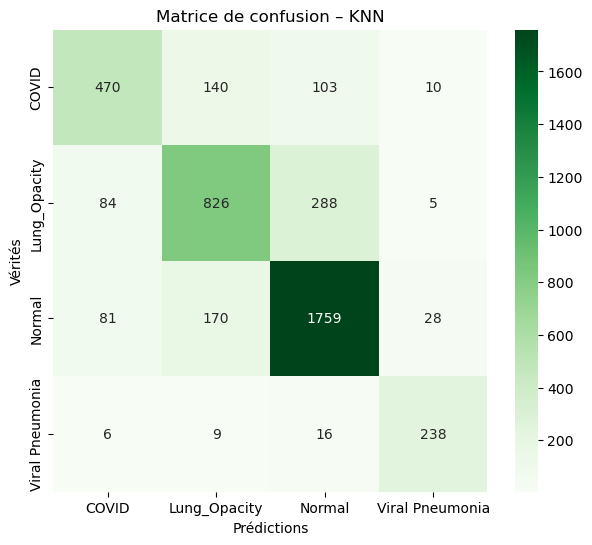


Analyse du modèle KNN :
- Le modèle KNN classe les images en fonction de leurs voisins les plus proches.
- Ce modèle est simple mais peut être sensible au bruit et à la dimension élevée des images.
- Sur des images médicales, les performances sont souvent inférieures aux modèles comme Random Forest ou CNN.


In [21]:
# =============================================================
# STEP 2.2 – Machine Learning : K-Nearest Neighbors (KNN)
# =============================================================

# Import du modèle KNN
from sklearn.neighbors import KNeighborsClassifier

# Import des métriques d'évaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------------------------
# 1) Création du modèle KNN
# ------------------------------------------------------------

# Le modèle KNN fonctionne en comparant chaque image avec ses voisins
# les plus proches dans l’espace des features.

# n_neighbors = nombre de voisins utilisés pour décider de la classe
# Ici on choisit 5 voisins (valeur classique)

knn_model = KNeighborsClassifier(
    n_neighbors=5,     # nombre de voisins
    weights='distance',# les voisins les plus proches ont plus d’importance
    metric='euclidean' # distance utilisée pour comparer les images
)

# ------------------------------------------------------------
# 2) Entraînement du modèle
# ------------------------------------------------------------

# Le modèle apprend les relations entre les pixels (features)
# et les classes (COVID, Normal, etc.)

print("\n=== Entraînement du modèle KNN ===")

knn_model.fit(X_train, y_train)

# ------------------------------------------------------------
# 3) Prédiction sur les données de test
# ------------------------------------------------------------

print("\n=== Prédiction avec le modèle KNN ===")

y_pred_knn = knn_model.predict(X_test)

# ------------------------------------------------------------
# 4) Accuracy globale
# ------------------------------------------------------------

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("\nAccuracy KNN :", round(accuracy_knn,4))

# ------------------------------------------------------------
# 5) Classification Report
# ------------------------------------------------------------

print("\n=== Classification Report – KNN ===")

print(classification_report(
    y_test,
    y_pred_knn,
    target_names=le.classes_
))

# ------------------------------------------------------------
# 6) Matrice de confusion
# ------------------------------------------------------------

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Matrice de confusion – KNN")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")

plt.savefig(os.path.join(save_dir, "matrice_confusion_KNN.png"))

plt.show()

# ------------------------------------------------------------
# 7) Analyse simple des résultats
# ------------------------------------------------------------

print("\nAnalyse du modèle KNN :")

print("- Le modèle KNN classe les images en fonction de leurs voisins les plus proches.")
print("- Ce modèle est simple mais peut être sensible au bruit et à la dimension élevée des images.")
print("- Sur des images médicales, les performances sont souvent inférieures aux modèles comme Random Forest ou CNN.")

In [ ]:
# =============================================================
# SAUVEGARDE DES MODELES pour Streamlit
# =============================================================
import joblib

models_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "models")
os.makedirs(models_dir, exist_ok=True)

# Sauvegarde du Random Forest optimise
joblib.dump(best_rf, os.path.join(models_dir, "random_forest_optimise.pkl"))
print("Random Forest optimise sauvegarde")

# Sauvegarde du KNN
joblib.dump(knn_model, os.path.join(models_dir, "knn.pkl"))
print("KNN sauvegarde")

# Sauvegarde du label mapping (index -> nom de classe)
label_mapping = {i: cls for i, cls in enumerate(le.classes_)}
joblib.dump(label_mapping, os.path.join(models_dir, "label_mapping.pkl"))
print("Label mapping sauvegarde:", label_mapping)

print("\nTous les modeles sont sauvegardes dans models/")